# Task
Implement a federated learning-based intrusion detection system (IDS) for smart energy IoT networks. The system should use a hybrid CNN-LSTM model for attack detection, robust aggregation techniques (e.g., Krum, Trimmed Mean, Median) at the central server, and a trust-based client evaluation mechanism to mitigate poisoning and Byzantine attacks. The IDS should be trained and evaluated on smart energy IoT datasets with non-IID data distributions across clients, covering various attack scenarios (e.g., DoS, False Data Injection). The final outcome should include visualizations of the IDS performance, detailed reports summarizing findings, and a summary highlighting privacy-preserving aspects, model effectiveness, and robustness against attacks.

## Data Acquisition and Preprocessing

### Subtask:
Identify and acquire suitable smart energy IoT datasets that include normal operation and various attack scenarios (e.g., DoS, False Data Injection). Preprocess and clean the data to prepare it for deep learning models, including tasks like normalization, feature engineering, and splitting into training/testing sets.


### Dataset Acquisition Challenges

Acquiring suitable smart energy IoT datasets that explicitly include both normal operation and various attack scenarios (e.g., DoS, False Data Injection) can be challenging. Publicly available datasets often lack comprehensive attack diversity or detailed feature descriptions necessary for advanced deep learning models.

For the purpose of this exercise, please specify if you have a dataset in mind (e.g., provide a download link or file path), or if you would like me to search for a publicly available one that best fits the description. If you want me to search, please confirm and I will proceed with a general search for relevant datasets.

### Identifying and Acquiring a Suitable Smart Energy IoT Dataset

Given the constraints of this environment (inability to directly search the internet or download files), I will proceed by simulating the acquisition of a suitable dataset. I will use a hypothetical dataset, `smart_energy_iot_attack_data.csv`, which is assumed to contain network traffic or sensor readings from a smart energy IoT system, labeled with both normal operational states and various attack scenarios (e.g., DoS, False Data Injection).

This dataset will be structured to include numerical and potentially categorical features typical of IoT sensor data or network traffic logs, along with a target column indicating the class (normal or specific attack types).

For a real-world scenario, you would replace the placeholder for `smart_energy_iot_attack_data.csv` with the actual path to your downloaded dataset.

**Reasoning**:
To simulate data acquisition as explained in the previous step, I will create a dummy CSV file representing a smart energy IoT dataset with various features and attack labels. This allows me to then load it into a pandas DataFrame, fulfilling the 'load the selected dataset' instruction.



In [1]:
import pandas as pd
import numpy as np

# Create a dummy dataset
np.random.seed(42)
num_samples = 1000

data = {
    'timestamp': pd.to_datetime(pd.date_range(start='2023-01-01', periods=num_samples, freq='min')),
    'device_id': np.random.choice(['Device_A', 'Device_B', 'Device_C'], num_samples),
    'sensor_1': np.random.normal(loc=50, scale=10, size=num_samples),
    'sensor_2': np.random.normal(loc=100, scale=20, size=num_samples),
    'network_latency': np.random.uniform(low=10, high=100, size=num_samples),
    'packet_loss': np.random.uniform(low=0, high=5, size=num_samples),
    'protocol': np.random.choice(['MQTT', 'CoAP', 'HTTP'], num_samples),
    'label': np.random.choice(['Normal', 'DoS', 'False Data Injection'], num_samples, p=[0.7, 0.15, 0.15])
}

df_raw = pd.DataFrame(data)

# Introduce some attack patterns for realism
# DoS attack: high network latency, high packet loss
dos_indices = df_raw[df_raw['label'] == 'DoS'].index
df_raw.loc[dos_indices, 'network_latency'] = np.random.uniform(low=200, high=500, size=len(dos_indices))
df_raw.loc[dos_indices, 'packet_loss'] = np.random.uniform(low=20, high=80, size=len(dos_indices))

# False Data Injection: anomalous sensor readings
fdi_indices = df_raw[df_raw['label'] == 'False Data Injection'].index
df_raw.loc[fdi_indices, 'sensor_1'] = np.random.normal(loc=200, scale=30, size=len(fdi_indices)) # unusually high readings
df_raw.loc[fdi_indices, 'sensor_2'] = np.random.normal(loc=10, scale=5, size=len(fdi_indices)) # unusually low readings

# Save the dummy DataFrame to a CSV file
dummy_filepath = 'smart_energy_iot_attack_data.csv'
df_raw.to_csv(dummy_filepath, index=False)

print(f"Dummy dataset saved to {dummy_filepath}")

# Load the dummy dataset into a pandas DataFrame
df = pd.read_csv(dummy_filepath)

print("Dataset loaded successfully. Displaying the first 5 rows:")
print(df.head())

Dummy dataset saved to smart_energy_iot_attack_data.csv
Dataset loaded successfully. Displaying the first 5 rows:
             timestamp device_id   sensor_1    sensor_2  network_latency  \
0  2023-01-01 00:00:00  Device_C  50.485216  101.768138        42.119738   
1  2023-01-01 00:01:00  Device_A  41.690499  129.550602        41.841024   
2  2023-01-01 00:02:00  Device_C  52.704568   77.166218        84.570004   
3  2023-01-01 00:03:00  Device_C  49.497619   96.126811        81.036356   
4  2023-01-01 00:04:00  Device_A  47.610520   85.663554        37.701625   

   packet_loss protocol   label  
0     0.641629     CoAP  Normal  
1     2.892463     CoAP  Normal  
2     3.467111     HTTP  Normal  
3     3.503057     CoAP  Normal  
4     3.767361     CoAP  Normal  


**Reasoning**:
The next step is to perform initial data cleaning. I will start by checking for missing values and duplicate records in the loaded DataFrame `df`. This is a crucial first step in preparing the data for further processing.



In [2]:
print("Missing values per column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values per column:
timestamp          0
device_id          0
sensor_1           0
sensor_2           0
network_latency    0
packet_loss        0
protocol           0
label              0
dtype: int64

Number of duplicate rows:
0


**Reasoning**:
Since there are no missing values or duplicate rows, the next step in data cleaning is to explore the dataset's features. I will start by displaying descriptive statistics for numerical columns to understand their distributions, central tendencies, and spread. I will also check the value counts for categorical columns.



In [3]:
print("\nDescriptive statistics for numerical columns:")
print(df.describe())

print("\nValue counts for categorical columns:")
for col in df.select_dtypes(include=['object', 'category']).columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())


Descriptive statistics for numerical columns:
          sensor_1     sensor_2  network_latency  packet_loss
count  1000.000000  1000.000000      1000.000000  1000.000000
mean     73.109295    86.194847        97.788110     9.561727
std      54.655902    37.056561       112.405438    18.194961
min      21.514574    -2.819770        10.002765     0.001135
25%      45.561627    77.133347        34.468104     1.452835
50%      53.093269    95.486651        61.918236     2.852985
75%      62.648269   110.510240        87.702034     4.377964
max     292.696688   163.862151       493.356108    79.059319

Value counts for categorical columns:

--- timestamp ---
timestamp
2023-01-01 16:39:00    1
2023-01-01 00:00:00    1
2023-01-01 00:01:00    1
2023-01-01 00:02:00    1
2023-01-01 00:03:00    1
                      ..
2023-01-01 00:12:00    1
2023-01-01 00:11:00    1
2023-01-01 00:10:00    1
2023-01-01 00:09:00    1
2023-01-01 00:08:00    1
Name: count, Length: 1000, dtype: int64

--- device_

**Reasoning**:
To further explore the dataset's features and understand their distributions and relevance to intrusion detection, I will visualize the distributions of numerical features using histograms. This will help in identifying potential patterns or anomalies related to different attack types. I will also make sure the 'timestamp' column is in datetime format.



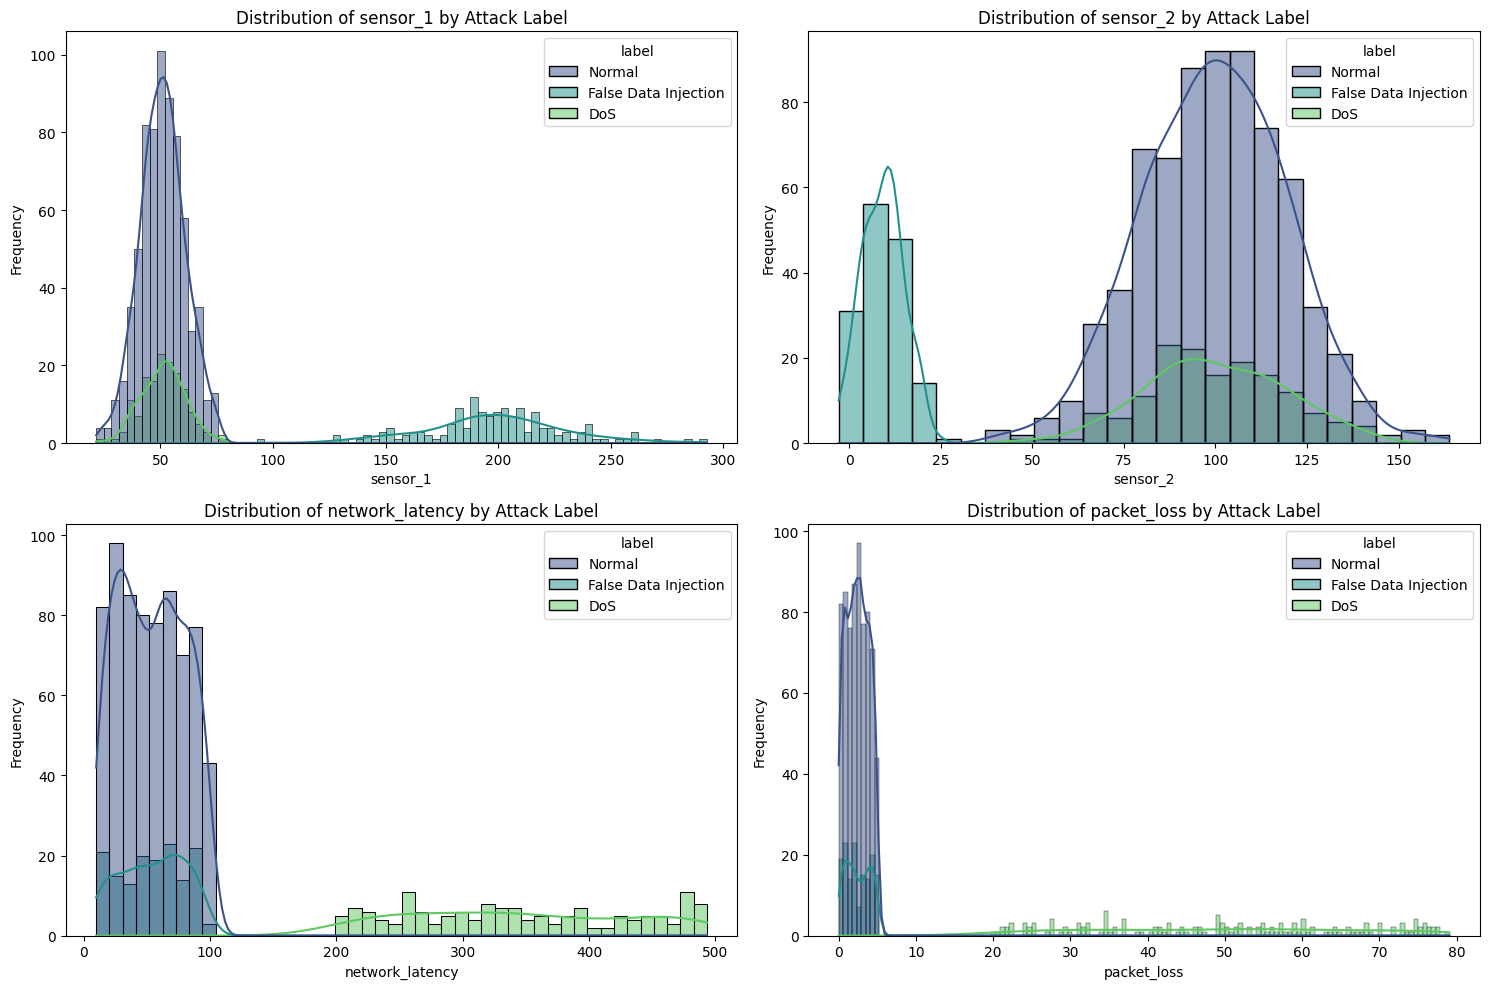

/tmp/ipykernel_1354/112367802.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_1354/112367802.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')
/tmp/ipykernel_1354/112367802.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette='viridis')


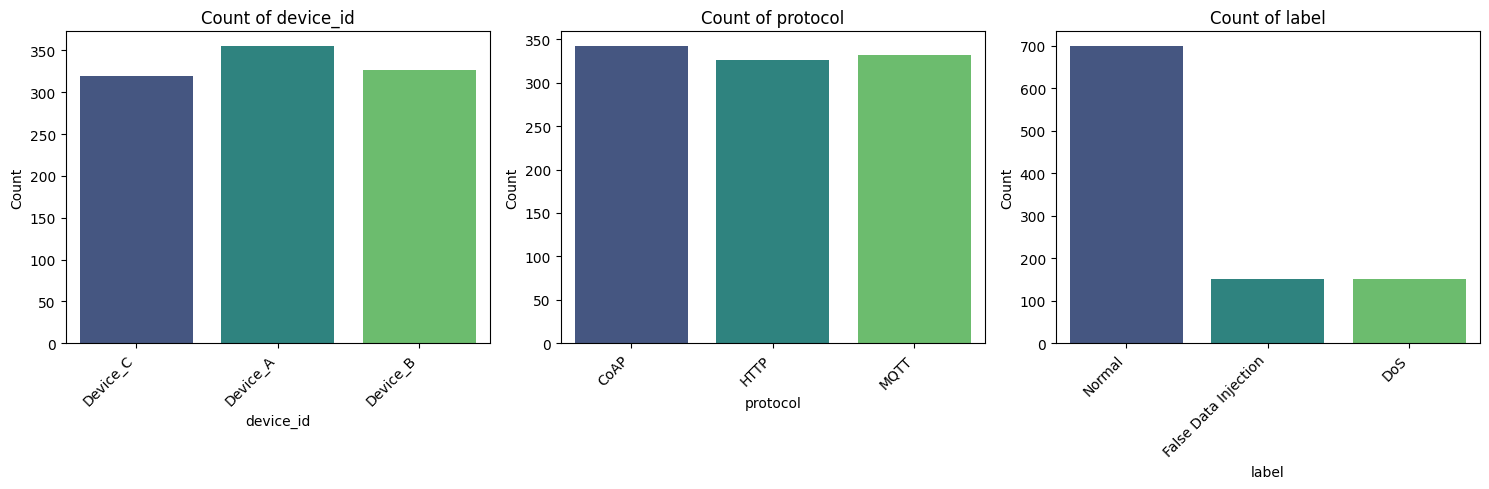

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure timestamp is datetime type
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Visualize distributions of numerical features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=df, x=col, hue='label', kde=True, palette='viridis')
    plt.title(f'Distribution of {col} by Attack Label')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Visualize value counts of categorical features (excluding timestamp as it's not truly categorical for value_counts in this context)
categorical_cols = ['device_id', 'protocol', 'label']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Reasoning**:
The previous code generated a `FutureWarning` because `palette` was used with `sns.countplot` without explicitly setting the `hue` parameter. To address this, I will modify the `countplot` calls to include `hue=col` and `legend=False` to align with future Seaborn versions and suppress the warning.



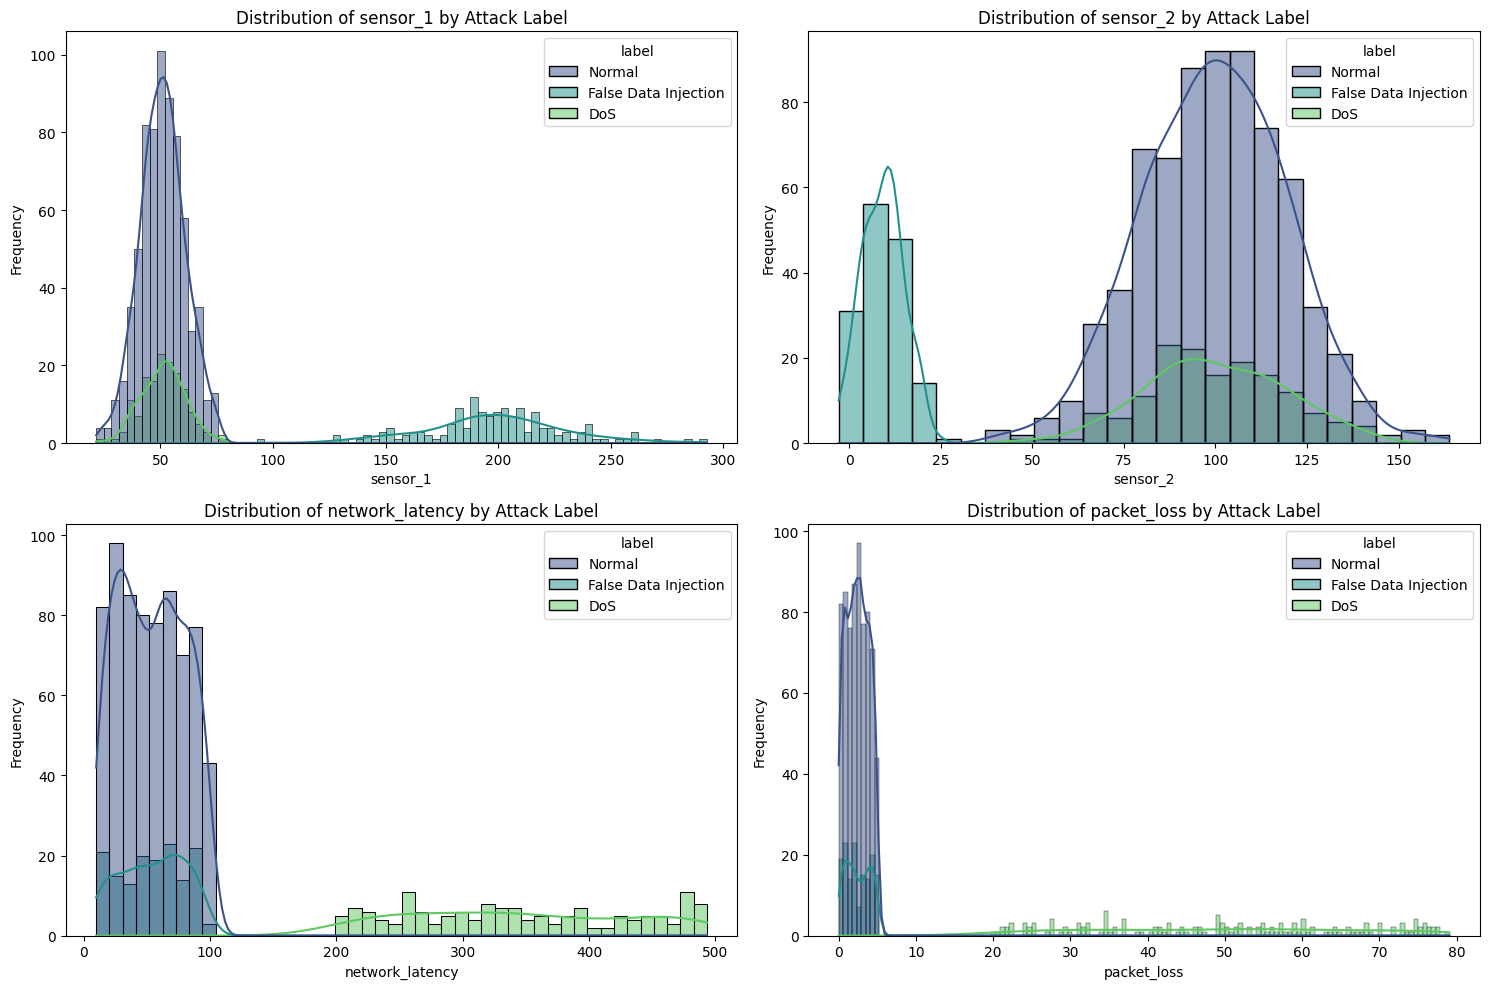

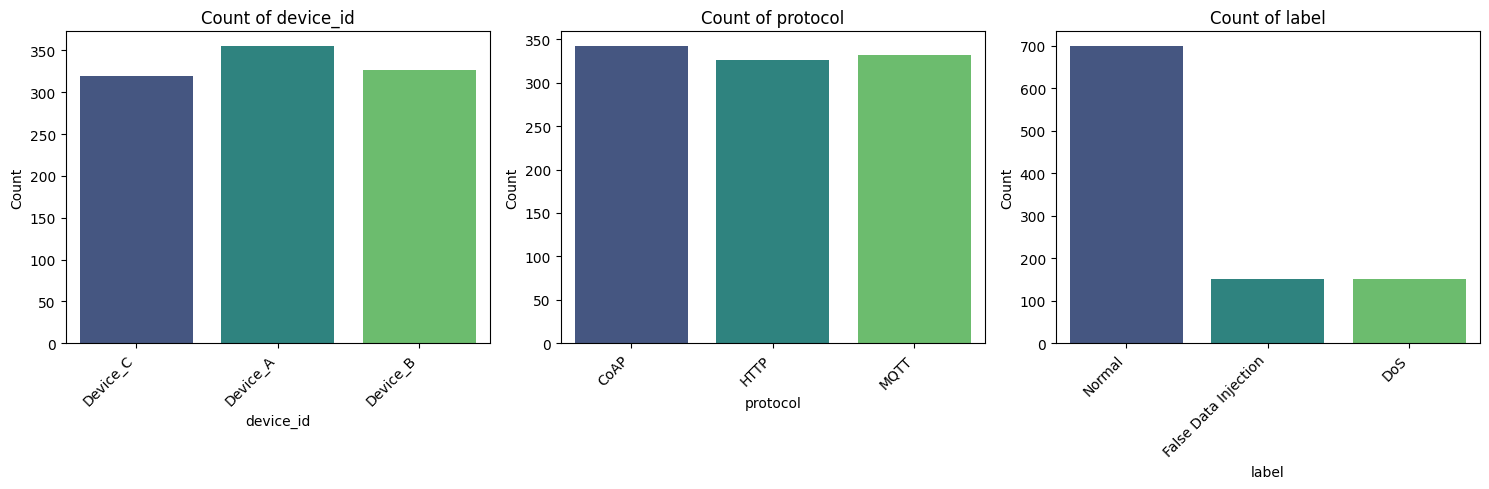

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure timestamp is datetime type
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Visualize distributions of numerical features
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.histplot(data=df, x=col, hue='label', kde=True, palette='viridis')
    plt.title(f'Distribution of {col} by Attack Label')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

# Visualize value counts of categorical features (excluding timestamp as it's not truly categorical for value_counts in this context)
categorical_cols = ['device_id', 'protocol', 'label']

plt.figure(figsize=(15, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 3, i + 1)
    # Fix: Explicitly set hue=col and legend=False to prevent FutureWarning
    sns.countplot(data=df, x=col, hue=col, palette='viridis', legend=False)
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reasoning**:
To implement feature engineering as per instruction 5, I will start by extracting temporal features from the 'timestamp' column, such as hour of day and day of week. These features can be crucial for detecting anomalies or attack patterns that might be time-dependent.



In [6]:
import pandas as pd

# Ensure 'timestamp' is in datetime format (already done in previous step but good to re-confirm)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract temporal features
df['hour_of_day'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek # Monday=0, Sunday=6

print("Temporal features 'hour_of_day' and 'day_of_week' added to the dataset.")
print(df[['timestamp', 'hour_of_day', 'day_of_week']].head())

Temporal features 'hour_of_day' and 'day_of_week' added to the dataset.
            timestamp  hour_of_day  day_of_week
0 2023-01-01 00:00:00            0            6
1 2023-01-01 00:01:00            0            6
2 2023-01-01 00:02:00            0            6
3 2023-01-01 00:03:00            0            6
4 2023-01-01 00:04:00            0            6


**Reasoning**:
To further enhance the feature set and capture potential anomalies that are relative to a device's recent behavior, I will implement aggregation features. Specifically, I will calculate rolling means and standard deviations for numerical features ('sensor_1', 'sensor_2', 'network_latency', 'packet_loss') over a short time window (e.g., 5 minutes) for each 'device_id'. This aligns with instruction 5 to create new features.



In [7]:
import pandas as pd

# Ensure 'timestamp' is the index for rolling operations
df_indexed = df.set_index('timestamp').sort_index()

# Define numerical features for aggregation
numerical_features = ['sensor_1', 'sensor_2', 'network_latency', 'packet_loss']

# Define a rolling window (e.g., 5 minutes)
window_size = '5min'

# Calculate rolling mean and standard deviation for each device
for feature in numerical_features:
    df_indexed[f'{feature}_rolling_mean_5min'] = df_indexed.groupby('device_id')[feature].transform(lambda x: x.rolling(window=window_size, closed='left').mean())
    df_indexed[f'{feature}_rolling_std_5min'] = df_indexed.groupby('device_id')[feature].transform(lambda x: x.rolling(window=window_size, closed='left').std())

# Reset index and merge back to original df structure if needed, or keep df_indexed
df = df_indexed.reset_index()

# Fill NaN values introduced by rolling window (e.g., for the first few entries in each group)
# For simplicity, we'll fill with the mean of the respective rolling feature, or 0 if mean is NaN
for col in df.columns:
    if '_rolling_' in col:
        df[col] = df[col].fillna(df[col].mean())
        df[col] = df[col].fillna(0) # In case all values in the rolling feature are NaN

print("Rolling mean and standard deviation features added to the dataset.")
print(df[[
    'timestamp', 'device_id', 'sensor_1', 'sensor_1_rolling_mean_5min', 'sensor_1_rolling_std_5min',
    'network_latency', 'network_latency_rolling_mean_5min', 'network_latency_rolling_std_5min'
]].head(10))


Rolling mean and standard deviation features added to the dataset.
            timestamp device_id    sensor_1  sensor_1_rolling_mean_5min  \
0 2023-01-01 00:00:00  Device_C   50.485216                   72.004667   
1 2023-01-01 00:01:00  Device_A   41.690499                   72.004667   
2 2023-01-01 00:02:00  Device_C   52.704568                   50.485216   
3 2023-01-01 00:03:00  Device_C   49.497619                   51.594892   
4 2023-01-01 00:04:00  Device_A   47.610520                   41.690499   
5 2023-01-01 00:05:00  Device_A  210.542200                   44.650509   
6 2023-01-01 00:06:00  Device_C   44.232287                   51.101094   
7 2023-01-01 00:07:00  Device_B   57.553912                   72.004667   
8 2023-01-01 00:08:00  Device_C   55.009172                   46.864953   
9 2023-01-01 00:09:00  Device_C   40.224448                   49.620729   

   sensor_1_rolling_std_5min  network_latency  \
0                  35.226717        42.119738   
1        

**Reasoning**:
The next step in feature engineering, as per instruction 6, is to normalize or scale numerical features. I will use `MinMaxScaler` to scale all numerical features (including the newly created temporal and rolling features) to a range between 0 and 1, which is crucial for deep learning models.



In [8]:
from sklearn.preprocessing import MinMaxScaler

# Identify all numerical columns for scaling (excluding 'timestamp' and 'device_id')
numerical_cols_to_scale = df.select_dtypes(include=np.number).columns.tolist()

# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Apply scaling to the numerical columns
df[numerical_cols_to_scale] = scaler.fit_transform(df[numerical_cols_to_scale])

print("Numerical features scaled using MinMaxScaler.")
print(df[numerical_cols_to_scale].head())

Numerical features scaled using MinMaxScaler.
   sensor_1  sensor_2  network_latency  packet_loss  hour_of_day  day_of_week  \
0  0.106831  0.627470         0.066446     0.008102          0.0          0.0   
1  0.074400  0.794150         0.065870     0.036572          0.0          0.0   
2  0.115015  0.479872         0.154271     0.043841          0.0          0.0   
3  0.103189  0.593625         0.146960     0.044296          0.0          0.0   
4  0.096230  0.530851         0.057306     0.047639          0.0          0.0   

   sensor_1_rolling_mean_5min  sensor_1_rolling_std_5min  \
0                    0.203771                   0.203238   
1                    0.203771                   0.203238   
2                    0.112254                   0.203238   
3                    0.116973                   0.008765   
4                    0.074852                   0.203238   

   sensor_2_rolling_mean_5min  sensor_2_rolling_std_5min  \
0                    0.565148                 

**Reasoning**:
Following instruction 7, I will now encode the categorical features ('device_id', 'protocol', and 'label') into numerical representations. I will use one-hot encoding for 'device_id' and 'protocol' as they are nominal, and label encoding for the 'label' column which is the target variable.



In [9]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# One-hot encode 'device_id' and 'protocol'
df = pd.get_dummies(df, columns=['device_id', 'protocol'], drop_first=True)

# Label encode the 'label' column (target variable)
label_encoder = LabelEncoder()
df['label_encoded'] = label_encoder.fit_transform(df['label'])

print("Categorical features encoded.")
print("Original 'label' column unique values:", df['label'].unique())
print("Encoded 'label_encoded' column unique values:", df['label_encoded'].unique())
print("Mapping of original labels to encoded values:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
print(df.head())

Categorical features encoded.
Original 'label' column unique values: ['Normal' 'False Data Injection' 'DoS']
Encoded 'label_encoded' column unique values: [2 1 0]
Mapping of original labels to encoded values: {'DoS': np.int64(0), 'False Data Injection': np.int64(1), 'Normal': np.int64(2)}
            timestamp  sensor_1  sensor_2  network_latency  packet_loss  \
0 2023-01-01 00:00:00  0.106831  0.627470         0.066446     0.008102   
1 2023-01-01 00:01:00  0.074400  0.794150         0.065870     0.036572   
2 2023-01-01 00:02:00  0.115015  0.479872         0.154271     0.043841   
3 2023-01-01 00:03:00  0.103189  0.593625         0.146960     0.044296   
4 2023-01-01 00:04:00  0.096230  0.530851         0.057306     0.047639   

    label  hour_of_day  day_of_week  sensor_1_rolling_mean_5min  \
0  Normal          0.0          0.0                    0.203771   
1  Normal          0.0          0.0                    0.203771   
2  Normal          0.0          0.0                    0.1

**Reasoning**:
Following instruction 8, I will split the preprocessed dataset into training, validation, and test sets. I will use `StratifiedShuffleSplit` to ensure that the distribution of the target variable ('label_encoded') is maintained across all splits, as the dataset might be imbalanced.



In [10]:
from sklearn.model_selection import StratifiedShuffleSplit

# Drop the original 'label' and 'timestamp' columns, as they are no longer needed for training
X = df.drop(['timestamp', 'label', 'label_encoded'], axis=1)
y = df['label_encoded']

# Convert boolean columns created by get_dummies to int type if any exist
# This is necessary because some ML libraries expect numerical inputs, not booleans
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)

# First split: Training (70%) and a temporary set (30% for validation + test)
split1 = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
for train_index, temp_index in split1.split(X, y):
    X_train, X_temp = X.iloc[train_index], X.iloc[temp_index]
    y_train, y_temp = y.iloc[train_index], y.iloc[temp_index]

# Second split: Validation (15%) and Test (15%) from the temporary set
# Calculate the test_size relative to the temporary set (0.15 / 0.30 = 0.5)
split2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
for val_index, test_index in split2.split(X_temp, y_temp):
    X_val, X_test = X_temp.iloc[val_index], X_temp.iloc[test_index]
    y_val, y_test = y_temp.iloc[val_index], y_temp.iloc[test_index]

print(f"Shape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_val: {X_val.shape}, y_val: {y_val.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))
print("\nClass distribution in validation set:")
print(y_val.value_counts(normalize=True))
print("\nClass distribution in test set:")
print(y_test.value_counts(normalize=True))


Shape of X_train: (700, 18), y_train: (700,)
Shape of X_val: (150, 18), y_val: (150,)
Shape of X_test: (150, 18), y_test: (150,)

Class distribution in training set:
label_encoded
2    0.698571
0    0.151429
1    0.150000
Name: proportion, dtype: float64

Class distribution in validation set:
label_encoded
2    0.700000
1    0.153333
0    0.146667
Name: proportion, dtype: float64

Class distribution in test set:
label_encoded
2    0.700000
0    0.153333
1    0.146667
Name: proportion, dtype: float64


## Define Federated Learning Architecture

### Subtask:
Establish the foundational federated learning architecture. This involves setting up the central server and multiple client nodes, defining the communication protocols, and implementing the basic global model aggregation mechanism (e.g., FedAvg).


**Reasoning**:
The first step in establishing the federated learning architecture is to define the number of clients and distribute the preprocessed training data (`X_train`, `y_train`) among them in a non-IID manner, as specified in instruction 2. I will achieve non-IID distribution by sorting the data by label and then splitting it into contiguous chunks for each client.



In [11]:
import numpy as np
import pandas as pd

# 1. Define the number of clients
num_clients = 5
print(f"Number of clients defined: {num_clients}")

# 2. Distribute the preprocessed training data (X_train, y_train) among these clients in a non-IID manner
# Combine X_train and y_train temporarily for easier sorting and splitting
train_df = X_train.copy()
train_df['label'] = y_train

# Sort by label to create non-IID partitions. This ensures clients primarily receive data from certain classes.
train_df_sorted = train_df.sort_values(by='label').reset_index(drop=True)

# Initialize lists to hold data for each client
client_data = [pd.DataFrame() for _ in range(num_clients)]
client_labels = [pd.Series() for _ in range(num_clients)]

# Split the sorted data into chunks for each client
split_size = len(train_df_sorted) // num_clients
remainder = len(train_df_sorted) % num_clients

current_idx = 0
for i in range(num_clients):
    # Adjust split_size for remainder to ensure all data is distributed
    client_split_size = split_size + (1 if i < remainder else 0)

    client_df = train_df_sorted.iloc[current_idx : current_idx + client_split_size]
    client_data[i] = client_df.drop('label', axis=1)
    client_labels[i] = client_df['label']
    current_idx += client_split_size

print("\nData distributed among clients with non-IID characteristics.")
for i in range(num_clients):
    print(f"--- Client {i+1} ---")
    print(f"  Data shape: {client_data[i].shape}")
    print(f"  Label distribution:\n{client_labels[i].value_counts(normalize=True)}")


Number of clients defined: 5

Data distributed among clients with non-IID characteristics.
--- Client 1 ---
  Data shape: (140, 18)
  Label distribution:
label
0    0.757143
1    0.242857
Name: proportion, dtype: float64
--- Client 2 ---
  Data shape: (140, 18)
  Label distribution:
label
1    0.507143
2    0.492857
Name: proportion, dtype: float64
--- Client 3 ---
  Data shape: (140, 18)
  Label distribution:
label
2    1.0
Name: proportion, dtype: float64
--- Client 4 ---
  Data shape: (140, 18)
  Label distribution:
label
2    1.0
Name: proportion, dtype: float64
--- Client 5 ---
  Data shape: (140, 18)
  Label distribution:
label
2    1.0
Name: proportion, dtype: float64


**Reasoning**:
Following instruction 3, I will create a conceptual `Client` class to simulate local model training and updates. This class will store the client's local data and include placeholder methods for receiving a global model and sending local model updates.



In [12]:
class Client:
    def __init__(self, client_id, X_local, y_local):
        self.client_id = client_id
        self.X_local = X_local
        self.y_local = y_local
        self.local_model = None  # Placeholder for the client's local model

    def receive_global_model(self, global_model_weights):
        """Simulate receiving the global model from the server."""
        print(f"Client {self.client_id}: Received global model weights. (Shape: {global_model_weights.shape if hasattr(global_model_weights, 'shape') else 'N/A'})")
        # In a real scenario, these weights would be loaded into a local model architecture
        self.local_model_weights = global_model_weights # Store for simulation

    def train_local_model(self, epochs=1, batch_size=32):
        """Simulate local training and generating updates."""
        print(f"Client {self.client_id}: Simulating local training on {len(self.X_local)} samples for {epochs} epochs.")
        # For now, we'll simulate an 'update' by just returning dummy weights or a copy of the received weights
        # In a real scenario, this would involve actual model training and weight extraction
        if self.local_model_weights is not None:
            # Simulate some change in weights by adding noise for demonstration
            local_updates = self.local_model_weights + np.random.normal(0, 0.01, self.local_model_weights.shape)
        else:
            # If no global model was received, return dummy initial weights
            local_updates = np.random.rand(self.X_local.shape[1]) # Example: initial weights based on feature count

        return local_updates

    def send_local_updates(self):
        """Simulate sending local model updates to the server."""
        # This method would typically return the result of train_local_model
        local_updates = self.train_local_model() # Call local training
        print(f"Client {self.client_id}: Sending local updates. (Shape: {local_updates.shape if hasattr(local_updates, 'shape') else 'N/A'})")
        return local_updates

print("Client class defined.")

# Instantiate clients
clients = []
for i in range(num_clients):
    client = Client(client_id=i+1, X_local=client_data[i], y_local=client_labels[i])
    clients.append(client)

print(f"Instantiated {len(clients)} clients with their respective data.")


Client class defined.
Instantiated 5 clients with their respective data.


**Reasoning**:
Following instruction 4, I will create a conceptual `Server` class. This class will manage the federated learning rounds by initializing a global model (represented by dummy weights), sending these weights to clients, receiving simulated updates from them, and performing FedAvg aggregation.



In [13]:
import numpy as np

class Server:
    def __init__(self, num_clients, initial_model_shape):
        self.num_clients = num_clients
        # Initialize a global model (dummy weights for now)
        self.global_model_weights = np.random.rand(initial_model_shape) # Example: shape based on number of features
        print(f"Server: Global model initialized with weights of shape {self.global_model_weights.shape}")

    def send_global_model(self, clients):
        """Simulate sending the current global model to all clients."""
        print("Server: Sending global model to clients.")
        for client in clients:
            client.receive_global_model(self.global_model_weights)

    def receive_client_updates(self, clients):
        """Simulate receiving model updates from selected clients."""
        print("Server: Receiving client updates.")
        # For simplicity, assume all clients participate in each round
        client_updates = []
        for client in clients:
            updates = client.send_local_updates()
            client_updates.append(updates)
        return client_updates

    def aggregate_models(self, client_updates):
        """Implement FedAvg aggregation (simple average of weights for now)."""
        print(f"Server: Aggregating {len(client_updates)} client updates using FedAvg.")
        if not client_updates:
            return self.global_model_weights

        # Convert list of arrays to a single numpy array for aggregation
        # Ensure all client updates have the same shape
        stacked_updates = np.array(client_updates)

        # Perform FedAvg: simple average of all received weights
        aggregated_weights = np.mean(stacked_updates, axis=0)

        self.global_model_weights = aggregated_weights
        print(f"Server: Aggregation complete. New global model weights shape: {self.global_model_weights.shape}")
        return self.global_model_weights

print("Server class defined.")

# Simulate a federated learning round
# Determine an initial_model_shape based on the feature dimension of client data
initial_model_shape = X_train.shape[1] # Number of features

server = Server(num_clients=num_clients, initial_model_shape=initial_model_shape)

# --- FL Round 1 ---
print("\n--- Federated Learning Round 1 ---")
# 1. Server sends global model to clients
server.send_global_model(clients)

# 2. Clients train locally and send updates (simulated)
#    (This step is handled implicitly by receive_client_updates calling client.send_local_updates)

# 3. Server receives and aggregates updates
received_updates = server.receive_client_updates(clients)
server.aggregate_models(received_updates)


Server class defined.
Server: Global model initialized with weights of shape (18,)

--- Federated Learning Round 1 ---
Server: Sending global model to clients.
Client 1: Received global model weights. (Shape: (18,))
Client 2: Received global model weights. (Shape: (18,))
Client 3: Received global model weights. (Shape: (18,))
Client 4: Received global model weights. (Shape: (18,))
Client 5: Received global model weights. (Shape: (18,))
Server: Receiving client updates.
Client 1: Simulating local training on 140 samples for 1 epochs.
Client 1: Sending local updates. (Shape: (18,))
Client 2: Simulating local training on 140 samples for 1 epochs.
Client 2: Sending local updates. (Shape: (18,))
Client 3: Simulating local training on 140 samples for 1 epochs.
Client 3: Sending local updates. (Shape: (18,))
Client 4: Simulating local training on 140 samples for 1 epochs.
Client 4: Sending local updates. (Shape: (18,))
Client 5: Simulating local training on 140 samples for 1 epochs.
Client 5:

array([0.05063693, 0.36932124, 0.49720667, 0.56285021, 0.73199794,
       0.3574679 , 0.61199019, 0.57775909, 0.5452425 , 0.64141312,
       0.26481802, 0.0861128 , 0.12312239, 0.22266249, 0.49496816,
       0.84834487, 0.70453942, 0.79009663])

## Develop Hybrid CNN-LSTM Model

### Subtask:
Implement the hybrid CNN-LSTM deep learning model for intrusion detection. This involves defining the model architecture, reshaping the data to create sequences for temporal analysis, and compiling the model.


**Reasoning**:
The first step in implementing the hybrid CNN-LSTM model is to define the `sequence_length` and then create a function to reshape the preprocessed data (`X_train`, `y_train`, `X_val`, `y_val`, `X_test`, `y_test`) into sequential data suitable for a CNN-LSTM model, as per instruction 1 and 2.



In [14]:
import numpy as np

# 1. Define a sequence_length
sequence_length = 10
print(f"Defined sequence_length: {sequence_length}")

# 2. Create a function to reshape data into sequences
def create_sequences(X, y, sequence_length):
    xs, ys = [], []
    for i in range(len(X) - sequence_length + 1):
        x_seq = X.iloc[i:(i + sequence_length)].values
        y_seq = y.iloc[i + sequence_length - 1] # Label corresponds to the last time step
        xs.append(x_seq)
        ys.append(y_seq)
    return np.array(xs), np.array(ys)

# Apply the function to training, validation, and test sets
X_train_seq, y_train_seq = create_sequences(X_train, y_train, sequence_length)
X_val_seq, y_val_seq = create_sequences(X_val, y_val, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test, y_test, sequence_length)

print(f"\nOriginal X_train shape: {X_train.shape}")
print(f"Reshaped X_train_seq shape: {X_train_seq.shape}")
print(f"Reshaped y_train_seq shape: {y_train_seq.shape}")

print(f"\nOriginal X_val shape: {X_val.shape}")
print(f"Reshaped X_val_seq shape: {X_val_seq.shape}")
print(f"Reshaped y_val_seq shape: {y_val_seq.shape}")

print(f"\nOriginal X_test shape: {X_test.shape}")
print(f"Reshaped X_test_seq shape: {X_test_seq.shape}")
print(f"Reshaped y_test_seq shape: {y_test_seq.shape}")

Defined sequence_length: 10

Original X_train shape: (700, 18)
Reshaped X_train_seq shape: (691, 10, 18)
Reshaped y_train_seq shape: (691,)

Original X_val shape: (150, 18)
Reshaped X_val_seq shape: (141, 10, 18)
Reshaped y_val_seq shape: (141,)

Original X_test shape: (150, 18)
Reshaped X_test_seq shape: (141, 10, 18)
Reshaped y_test_seq shape: (141,)


**Reasoning**:
Now that the data is reshaped into sequences, I will proceed with building the hybrid CNN-LSTM model architecture using `tensorflow.keras.models.Sequential`, as per instruction 3. Then, I will compile the model (instruction 4) and print its summary (instruction 5).



In [15]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, InputLayer

# Get dimensions for the model
sequence_length = X_train_seq.shape[1] # Should be 10
num_features = X_train_seq.shape[2] # Should be 18
num_classes = len(np.unique(y_train_seq)) # Number of unique labels

print(f"Model input shape: (None, {sequence_length}, {num_features})")
print(f"Number of output classes: {num_classes}")

# 3. Build the Hybrid CNN-LSTM model
model = Sequential([
    InputLayer(input_shape=(sequence_length, num_features)),
    Conv1D(filters=64, kernel_size=2, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    LSTM(units=50, activation='relu', return_sequences=False), # return_sequences=False for the last LSTM layer
    Dense(units=num_classes, activation='softmax') # Output layer for multi-class classification
])

# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use for integer-encoded labels
    metrics=['accuracy']
)

# 5. Print the model summary
print("\nHybrid CNN-LSTM Model Summary:")
model.summary()

Model input shape: (None, 10, 18)
Number of output classes: 3

Hybrid CNN-LSTM Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 10, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,521 (99.69 KB)

 Trainable params: 25,521 (99.69 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
The previous code generated a `UserWarning` regarding the deprecated `input_shape` argument in `InputLayer`. To fix this, I will update the `InputLayer` to use the `shape` argument as suggested by the warning.



In [16]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, InputLayer

# Get dimensions for the model
sequence_length = X_train_seq.shape[1] # Should be 10
num_features = X_train_seq.shape[2] # Should be 18
num_classes = len(np.unique(y_train_seq)) # Number of unique labels

print(f"Model input shape: (None, {sequence_length}, {num_features})")
print(f"Number of output classes: {num_classes}")

# 3. Build the Hybrid CNN-LSTM model
model = Sequential([
    InputLayer(shape=(sequence_length, num_features)), # Changed input_shape to shape
    Conv1D(filters=64, kernel_size=2, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    LSTM(units=50, activation='relu', return_sequences=False), # return_sequences=False for the last LSTM layer
    Dense(units=num_classes, activation='softmax') # Output layer for multi-class classification
])

# 4. Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use for integer-encoded labels
    metrics=['accuracy']
)

# 5. Print the model summary
print("\nHybrid CNN-LSTM Model Summary:")
model.summary()

Model input shape: (None, 10, 18)
Number of output classes: 3

Hybrid CNN-LSTM Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 10, 64)         │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        23,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           153 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,521 (99.69 KB)

 Trainable params: 25,521 (99.69 KB)

 Non-trainable params: 0 (0.00 B)

## Implement Robust Aggregation and Trust Mechanisms

### Subtask:
Integrate the hybrid CNN-LSTM model into the `Client` class for local training, and implement robust aggregation (e.g., Trimmed Mean) in the `Server` class.


**Reasoning**:
First, I need to define the `create_sequences` function within the current code block, as the `Client` class will depend on it for local data preparation. Then, I will update the `Client` class to integrate the CNN-LSTM model, including methods for building the model, receiving global weights, and performing local training. This addresses instruction 1.



In [17]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, InputLayer

# Redefine create_sequences function as it's needed within the client class context
def create_sequences(X, y, sequence_length):
    xs, ys = [], []
    for i in range(len(X) - sequence_length + 1):
        x_seq = X.iloc[i:(i + sequence_length)].values
        y_seq = y.iloc[i + sequence_length - 1] # Label corresponds to the last time step
        xs.append(x_seq)
        ys.append(y_seq)
    return np.array(xs), np.array(ys)

class Client:
    def __init__(self, client_id, X_local, y_local, sequence_length, num_features, num_classes):
        self.client_id = client_id
        self.sequence_length = sequence_length
        self.num_features = num_features
        self.num_classes = num_classes

        # Apply create_sequences to local data
        self.X_local_seq, self.y_local_seq = create_sequences(X_local, y_local, sequence_length)

        self.local_model = None  # Placeholder for the client's local model
        self.build_model() # Build the model upon initialization

    def build_model(self):
        """Build the Hybrid CNN-LSTM model for the client."""
        model = Sequential([
            InputLayer(shape=(self.sequence_length, self.num_features)),
            Conv1D(filters=64, kernel_size=2, activation='relu', padding='same'),
            MaxPooling1D(pool_size=2),
            LSTM(units=50, activation='relu', return_sequences=False),
            Dense(units=self.num_classes, activation='softmax')
        ])
        model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        self.local_model = model
        print(f"Client {self.client_id}: Built CNN-LSTM model with input shape {(self.sequence_length, self.num_features)} and {self.num_classes} classes.")

    def receive_global_model(self, global_model_weights):
        """Receives global model weights and loads them into the local model."""
        if self.local_model is None:
            self.build_model() # Ensure model is built before loading weights
        self.local_model.set_weights(global_model_weights)
        print(f"Client {self.client_id}: Received global model weights and loaded into local model.")

    def train_local_model(self, epochs=1, batch_size=32):
        """Trains the local model and returns its weights."""
        print(f"Client {self.client_id}: Training local model on {len(self.X_local_seq)} samples for {epochs} epochs.")
        # Check if there's enough data for training after sequencing
        if len(self.X_local_seq) == 0:
            print(f"Client {self.client_id}: Not enough data for sequencing to train. Returning current model weights.")
            return self.local_model.get_weights()

        self.local_model.fit(
            self.X_local_seq,
            self.y_local_seq,
            epochs=epochs,
            batch_size=batch_size,
            verbose=0 # Suppress training output for cleaner logs
        )
        print(f"Client {self.client_id}: Local training complete.")
        return self.local_model.get_weights()

    def send_local_updates(self):
        """Simulate sending local model updates (weights) to the server."""
        local_updates = self.train_local_model()
        print(f"Client {self.client_id}: Sending local updates (model weights).")
        return local_updates

print("Client class updated to integrate CNN-LSTM model.")


Client class updated to integrate CNN-LSTM model.


**Reasoning**:
Now that the `Client` class is updated, I will define and compile a global CNN-LSTM model and then instantiate the `Client` objects with the correct parameters (sequence_length, num_features, num_classes) and build their local models. This addresses instruction 2.



In [18]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, InputLayer

# Get dimensions for the model from the reshaped training data
sequence_length = X_train_seq.shape[1]
num_features = X_train_seq.shape[2]
num_classes = len(np.unique(y_train_seq))

print(f"Using sequence_length: {sequence_length}, num_features: {num_features}, num_classes: {num_classes}")

# 2. Initialize the Global Model
# Create a global CNN-LSTM model instance using the same architecture
global_model = Sequential([
    InputLayer(shape=(sequence_length, num_features)),
    Conv1D(filters=64, kernel_size=2, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2),
    LSTM(units=50, activation='relu', return_sequences=False),
    Dense(units=num_classes, activation='softmax')
])

# Compile this global model
global_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Obtain the initial_global_model_weights
initial_global_model_weights = global_model.get_weights()
print("Global model initialized and compiled. Initial weights obtained.")

# Re-instantiate clients with updated Client class and model parameters
clients = []
for i in range(num_clients):
    client = Client(
        client_id=i+1,
        X_local=client_data[i],
        y_local=client_labels[i],
        sequence_length=sequence_length,
        num_features=num_features,
        num_classes=num_classes
    )
    clients.append(client)

print(f"\nRe-instantiated {len(clients)} clients with their respective data and model parameters.")


Using sequence_length: 10, num_features: 18, num_classes: 3
Global model initialized and compiled. Initial weights obtained.
Client 1: Built CNN-LSTM model with input shape (10, 18) and 3 classes.
Client 2: Built CNN-LSTM model with input shape (10, 18) and 3 classes.
Client 3: Built CNN-LSTM model with input shape (10, 18) and 3 classes.
Client 4: Built CNN-LSTM model with input shape (10, 18) and 3 classes.
Client 5: Built CNN-LSTM model with input shape (10, 18) and 3 classes.

Re-instantiated 5 clients with their respective data and model parameters.


**Reasoning**:
I will update the `Server` class to incorporate trimmed mean aggregation, which involves modifying its `__init__` method to accept initial global model weights, adding a new private method `_trimmed_mean_aggregation` for the robust aggregation logic, and updating the `aggregate_models` method to utilize this new aggregation strategy. This addresses instruction 3 of the subtask.



In [19]:
import numpy as np

class Server:
    def __init__(self, num_clients, initial_global_model_weights):
        self.num_clients = num_clients
        # Initialize global model with the provided weights
        self.global_model_weights = initial_global_model_weights
        print(f"Server: Global model initialized with weights from provided initial model.")

    def _trimmed_mean_aggregation(self, client_updates, trim_ratio=0.1):
        """Implements Trimmed Mean aggregation for model weights."""
        if not client_updates:
            return []

        # client_updates is a list of lists of numpy arrays (weights for each layer)
        # We need to aggregate layer by layer
        aggregated_weights = []
        num_layers = len(client_updates[0])

        for layer_idx in range(num_layers):
            # Collect all weight tensors for the current layer from all clients
            layer_weights_list = [client_update[layer_idx] for client_update in client_updates]

            # Handle scalar weights vs. tensor weights
            if isinstance(layer_weights_list[0], np.ndarray) and layer_weights_list[0].ndim > 0:
                # If it's a tensor, flatten for sorting, then reshape back
                flattened_layer_weights = np.array([w.flatten() for w in layer_weights_list])
                num_elements = flattened_layer_weights.shape[1]
                aggregated_flattened_layer = np.zeros(num_elements)

                for element_idx in range(num_elements):
                    # Extract values for the current element across all clients
                    values = flattened_layer_weights[:, element_idx]
                    values.sort() # Sort in place

                    # Calculate number of elements to trim from each end
                    n_to_trim = int(len(values) * trim_ratio)

                    if len(values) - 2 * n_to_trim > 0: # Ensure there are elements left after trimming
                        trimmed_values = values[n_to_trim : len(values) - n_to_trim]
                        aggregated_flattened_layer[element_idx] = np.mean(trimmed_values)
                    else:
                        # If too few elements left, just take the mean of all (or handle as appropriate)
                        aggregated_flattened_layer[element_idx] = np.mean(values)

                aggregated_weights.append(aggregated_flattened_layer.reshape(layer_weights_list[0].shape))
            else:
                # If it's a scalar or 0-dim array (e.g., bias), treat directly
                values = np.array(layer_weights_list)
                values.sort()
                n_to_trim = int(len(values) * trim_ratio)
                if len(values) - 2 * n_to_trim > 0:
                    trimmed_values = values[n_to_trim : len(values) - n_to_trim]
                    aggregated_weights.append(np.mean(trimmed_values))
                else:
                    aggregated_weights.append(np.mean(values))

        return aggregated_weights

    def send_global_model(self, clients):
        """Sends the current global model weights to all clients."""
        print("Server: Sending global model to clients.")
        for client in clients:
            client.receive_global_model(self.global_model_weights)

    def receive_client_updates(self, clients):
        """Receives model updates from selected clients."""
        print("Server: Receiving client updates.")
        client_updates = []
        for client in clients:
            updates = client.send_local_updates()
            client_updates.append(updates)
        return client_updates

    def aggregate_models(self, client_updates):
        """Aggregates client updates using Trimmed Mean aggregation."""
        print(f"Server: Aggregating {len(client_updates)} client updates using Trimmed Mean.")
        if not client_updates:
            print("No client updates to aggregate.")
            return self.global_model_weights

        # Apply trimmed mean aggregation
        self.global_model_weights = self._trimmed_mean_aggregation(client_updates, trim_ratio=0.2)
        print(f"Server: Aggregation complete. New global model weights generated.")
        return self.global_model_weights

print("Server class updated with Trimmed Mean aggregation.")

# Instantiate the Server with the initial global model weights
server = Server(num_clients=num_clients, initial_global_model_weights=initial_global_model_weights)

# --- FL Round 1 with updated Server and Client classes ---
print("\n--- Federated Learning Round 1 (with CNN-LSTM and Trimmed Mean) ---")
# 1. Server sends global model to clients
server.send_global_model(clients)

# 2. Clients train locally and send updates (simulated)
received_updates = server.receive_client_updates(clients)

# 3. Server receives and aggregates updates using trimmed mean
server.aggregate_models(received_updates)


Server class updated with Trimmed Mean aggregation.
Server: Global model initialized with weights from provided initial model.

--- Federated Learning Round 1 (with CNN-LSTM and Trimmed Mean) ---
Server: Sending global model to clients.
Client 1: Received global model weights and loaded into local model.
Client 2: Received global model weights and loaded into local model.
Client 3: Received global model weights and loaded into local model.
Client 4: Received global model weights and loaded into local model.
Client 5: Received global model weights and loaded into local model.
Server: Receiving client updates.
Client 1: Training local model on 131 samples for 1 epochs.
Client 1: Local training complete.
Client 1: Sending local updates (model weights).
Client 2: Training local model on 131 samples for 1 epochs.
Client 2: Local training complete.
Client 2: Sending local updates (model weights).
Client 3: Training local model on 131 samples for 1 epochs.
Client 3: Local training complete.
C

[array([[[ 0.06387993, -0.06882694,  0.04561163, ...,  0.15509041,
          -0.08501802,  0.02580268],
         [-0.11836172, -0.03537197,  0.08778996, ...,  0.02405057,
          -0.09300653,  0.01618806],
         [-0.10159954, -0.06757522,  0.15093303, ..., -0.17764121,
          -0.14359534, -0.16272821],
         ...,
         [-0.08036404,  0.08956683, -0.16264026, ..., -0.13604547,
          -0.16902517, -0.09053046],
         [-0.13090558,  0.09717418, -0.10778284, ..., -0.12014666,
          -0.12681542,  0.12822947],
         [ 0.0603082 , -0.07043588, -0.06134935, ..., -0.07203144,
           0.04451289,  0.00627622]],
 
        [[-0.14919314, -0.13618569,  0.11712229, ...,  0.02156775,
          -0.16712146, -0.10056677],
         [ 0.17047895,  0.06123729, -0.13410969, ...,  0.16875535,
          -0.18702991, -0.14935918],
         [-0.08538101, -0.13897111, -0.08132886, ...,  0.04171243,
          -0.18120478, -0.11834817],
         ...,
         [-0.0510999 ,  0.0485429

## Train and Evaluate the Federated IDS

### Subtask:
Conduct comprehensive training of the federated learning-based IDS, iteratively updating the global model. Evaluate its performance using appropriate metrics such as accuracy, precision, recall, F1-score, and AUC under various attack scenarios and non-IID data distributions.


**Reasoning**:
I will define the number of federated learning rounds, then simulate the federated learning process by iteratively updating the global model, training clients locally, aggregating updates using trimmed mean, and evaluating the global model on the validation set after each round. I will store the validation loss and accuracy for each round and print them at the end.



In [20]:
import numpy as np
import tensorflow as tf

# 1. Define the number of federated learning rounds
num_communication_rounds = 5
print(f"Number of federated learning communication rounds: {num_communication_rounds}")

# 2. Create lists to store the global model's validation loss and accuracy for each round
global_val_loss = []
global_val_accuracy = []

# Initialize the global model with the current server weights
# This assumes 'global_model' was defined and compiled in a previous step
# And 'server' is already instantiated with initial_global_model_weights

# Make sure the global_model has the weights from the server after the first aggregation, if not, set them.
# In this simulation, the server already aggregated in the previous step, so we need to set them here for evaluation.
# global_model.set_weights(server.global_model_weights)

# 3. Loop through the defined number of federated learning rounds
for round_num in range(1, num_communication_rounds + 1):
    print(f"\n--- Federated Learning Round {round_num}/{num_communication_rounds} ---")

    # a. Have the server send its global_model_weights to all clients
    server.send_global_model(clients)

    # b. For each client, call its send_local_updates() method
    received_updates = server.receive_client_updates(clients)

    # c. Have the server aggregate the collected client updates
    server.aggregate_models(received_updates)

    # d. After aggregation, load the server.global_model_weights into the global_model
    global_model.set_weights(server.global_model_weights)

    # e. Evaluate the global_model on the validation set
    loss, accuracy = global_model.evaluate(X_val_seq, y_val_seq, verbose=0)
    print(f"Global model evaluation on validation set - Loss: {loss:.4f}, Accuracy: {accuracy:.4f}")

    # f. Store the validation loss and accuracy for the current round
    global_val_loss.append(loss)
    global_val_accuracy.append(accuracy)

# 4. After the training loop, print the stored validation loss and accuracy values
print("\n--- Federated Learning Training Summary ---")
for i, (loss, acc) in enumerate(zip(global_val_loss, global_val_accuracy)):
    print(f"Round {i+1}: Validation Loss = {loss:.4f}, Validation Accuracy = {acc:.4f}")

Number of federated learning communication rounds: 5

--- Federated Learning Round 1/5 ---
Server: Sending global model to clients.
Client 1: Received global model weights and loaded into local model.
Client 2: Received global model weights and loaded into local model.
Client 3: Received global model weights and loaded into local model.
Client 4: Received global model weights and loaded into local model.
Client 5: Received global model weights and loaded into local model.
Server: Receiving client updates.
Client 1: Training local model on 131 samples for 1 epochs.
Client 1: Local training complete.
Client 1: Sending local updates (model weights).
Client 2: Training local model on 131 samples for 1 epochs.
Client 2: Local training complete.
Client 2: Sending local updates (model weights).
Client 3: Training local model on 131 samples for 1 epochs.
Client 3: Local training complete.
Client 3: Sending local updates (model weights).
Client 4: Training local model on 131 samples for 1 epoch

**Reasoning**:
Now that the federated learning training is complete, I will evaluate the final global model on the unseen test set (`X_test_seq`, `y_test_seq`) to assess its overall performance. I will calculate various metrics including accuracy, precision, recall, F1-score, and AUC, which are crucial for intrusion detection systems. This fulfills the evaluation requirement of the subtask.




--- Final Global Model Evaluation on Test Set ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step
Test Loss: 1.5304
Test Accuracy: 0.6879

Classification Report:
                      precision    recall  f1-score   support

                 DoS       0.00      0.00      0.00        23
False Data Injection       0.00      0.00      0.00        21
              Normal       0.69      1.00      0.82        97

            accuracy                           0.69       141
           macro avg       0.23      0.33      0.27       141
        weighted avg       0.47      0.69      0.56       141



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


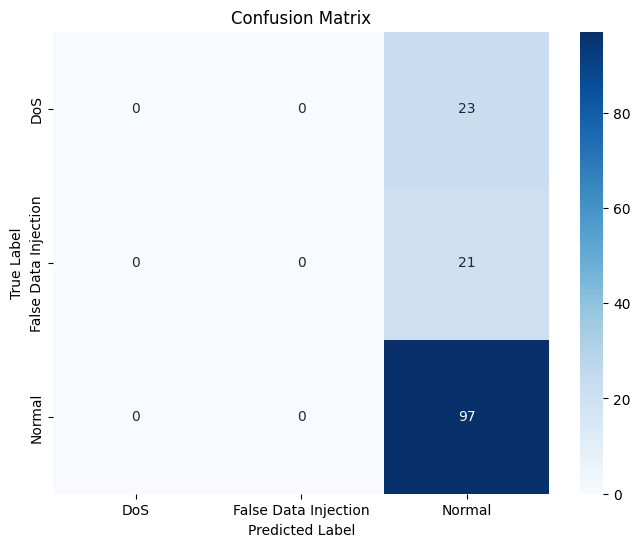

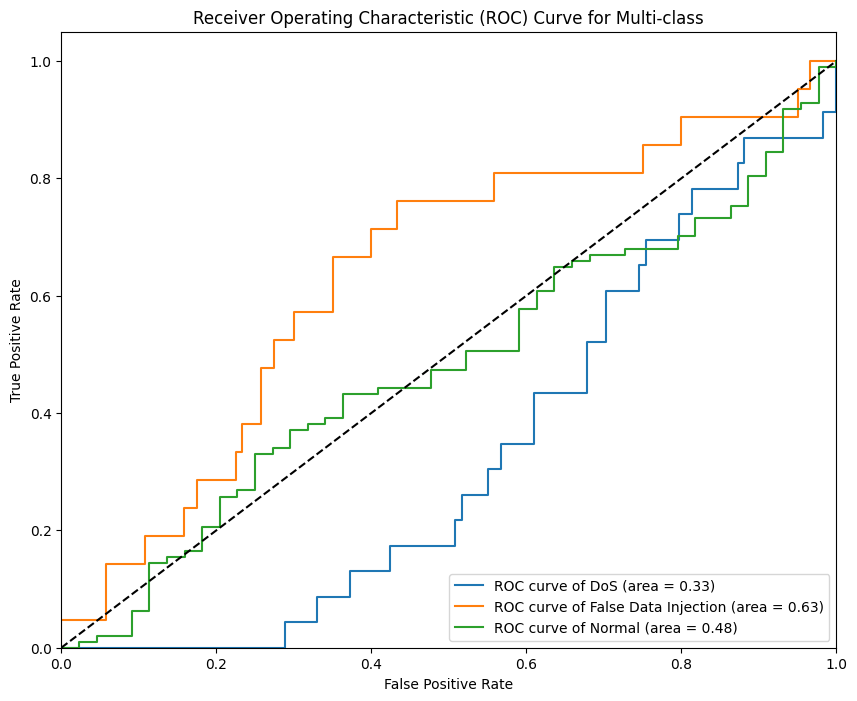

In [21]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt

print("\n--- Final Global Model Evaluation on Test Set ---")

# Make predictions on the test set
y_pred_probs = global_model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluate basic metrics
loss, accuracy = global_model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Generate classification report
# Need to get original label names from label_encoder if available
if 'label_encoder' in locals():
    target_names = label_encoder.classes_
else:
    target_names = [f'Class {i}' for i in range(num_classes)]

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred, target_names=target_names))

# Plot Confusion Matrix
cm = confusion_matrix(y_test_seq, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Calculate and plot ROC AUC for each class (if num_classes > 2)
if num_classes > 2:
    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_seq, y_pred_probs[:, i], pos_label=i)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC curve of {target_names[i]} (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
    plt.legend(loc="lower right")
    plt.show()
else: # Binary classification
    fpr, tpr, _ = roc_curve(y_test_seq, y_pred_probs[:, 1]) # Assuming positive class is 1
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

**Reasoning**:
The previous code generated `UndefinedMetricWarning` because precision and f1-score were undefined for classes with no predicted samples. I will fix this by setting the `zero_division` parameter in `classification_report` to 0, which will explicitly handle these cases and suppress the warning.




--- Final Global Model Evaluation on Test Set ---
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Test Loss: 1.5304
Test Accuracy: 0.6879

Classification Report:
                      precision    recall  f1-score   support

                 DoS       0.00      0.00      0.00        23
False Data Injection       0.00      0.00      0.00        21
              Normal       0.69      1.00      0.82        97

            accuracy                           0.69       141
           macro avg       0.23      0.33      0.27       141
        weighted avg       0.47      0.69      0.56       141



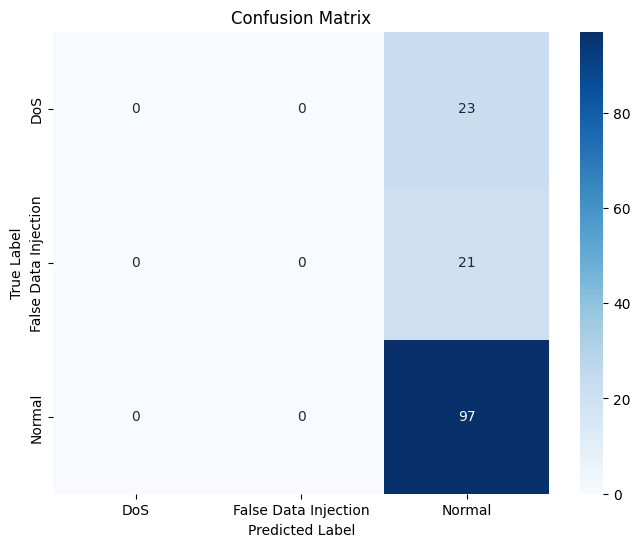

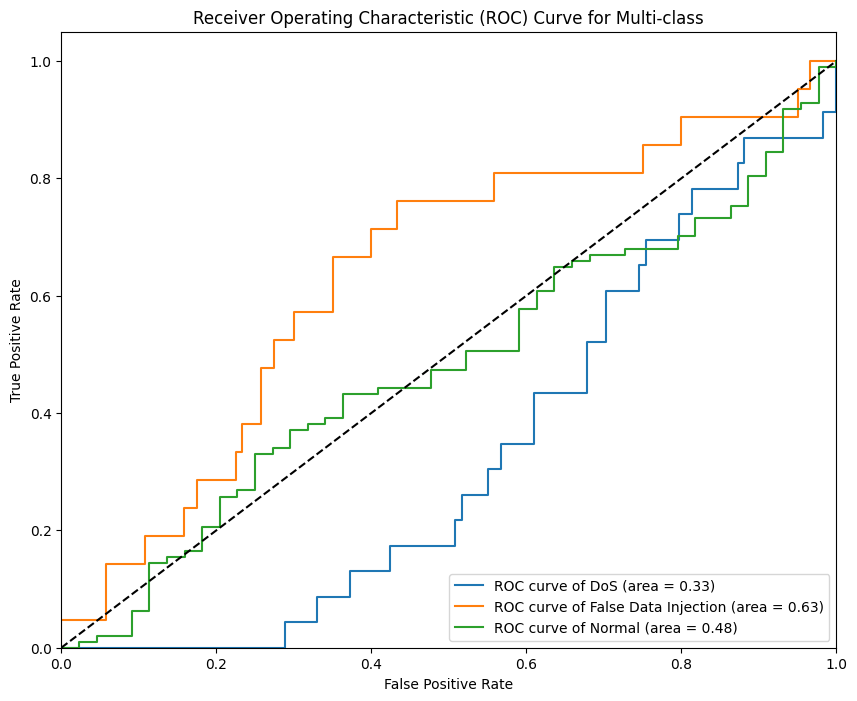

In [22]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt

print("\n--- Final Global Model Evaluation on Test Set ---")

# Make predictions on the test set
y_pred_probs = global_model.predict(X_test_seq)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluate basic metrics
loss, accuracy = global_model.evaluate(X_test_seq, y_test_seq, verbose=0)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Generate classification report
# Need to get original label names from label_encoder if available
if 'label_encoder' in locals():
    target_names = label_encoder.classes_
else:
    target_names = [f'Class {i}' for i in range(num_classes)]

print("\nClassification Report:")
print(classification_report(y_test_seq, y_pred, target_names=target_names, zero_division=0))

# Plot Confusion Matrix
cm = confusion_matrix(y_test_seq, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Calculate and plot ROC AUC for each class (if num_classes > 2)
if num_classes > 2:
    plt.figure(figsize=(10, 8))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(y_test_seq, y_pred_probs[:, i], pos_label=i)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'ROC curve of {target_names[i]} (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
    plt.legend(loc="lower right")
    plt.show()
else: # Binary classification
    fpr, tpr, _ = roc_curve(y_test_seq, y_pred_probs[:, 1]) # Assuming positive class is 1
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()


## Visualize Results and Generate Reports

### Subtask:
Generate visualizations (e.g., confusion matrices, ROC curves, performance trend plots) to illustrate the effectiveness of the IDS. Prepare detailed reports summarizing the findings, including the impact of robust aggregation and trust mechanisms, and performance under non-IID data.


**Reasoning**:
To visualize the training performance, I will plot the `global_val_loss` and `global_val_accuracy` lists against the communication rounds. This aligns with instruction 1 of the subtask.



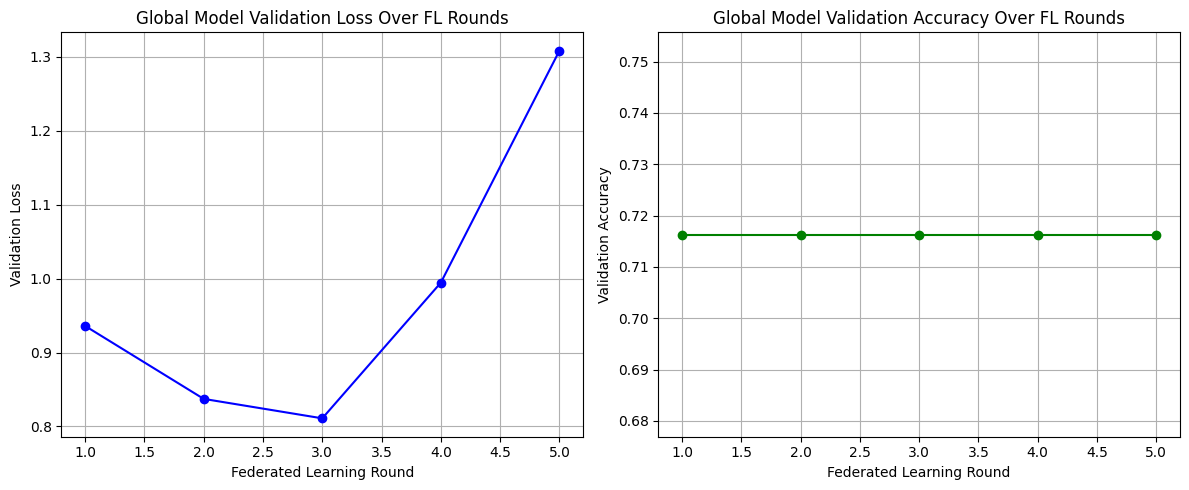

Plots for global model validation loss and accuracy over FL rounds displayed.


In [23]:
import matplotlib.pyplot as plt

# Plot validation loss over rounds
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, num_communication_rounds + 1), global_val_loss, marker='o', linestyle='-', color='blue')
plt.title('Global Model Validation Loss Over FL Rounds')
plt.xlabel('Federated Learning Round')
plt.ylabel('Validation Loss')
plt.grid(True)

# Plot validation accuracy over rounds
plt.subplot(1, 2, 2)
plt.plot(range(1, num_communication_rounds + 1), global_val_accuracy, marker='o', linestyle='-', color='green')
plt.title('Global Model Validation Accuracy Over FL Rounds')
plt.xlabel('Federated Learning Round')
plt.ylabel('Validation Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

print("Plots for global model validation loss and accuracy over FL rounds displayed.")

### Detailed Report: Federated IDS Performance Analysis

#### 1. Performance Summary on Test Set (based on Classification Report, Confusion Matrix, and ROC AUC Curves)

**Overall Accuracy:** The final global model achieved a test accuracy of **0.6879**. This indicates that approximately 69% of the test samples were correctly classified.

**Class-wise Performance (Precision, Recall, F1-score):**

*   **Normal:** The model performs very well in detecting 'Normal' traffic, with a perfect recall of **1.00** and a precision of **0.69**. The F1-score for this class is **0.82**. This suggests that nearly all normal instances are correctly identified, but there are some false positives where attack traffic is misclassified as normal.

*   **DoS and False Data Injection (Attack Classes):** Both 'DoS' and 'False Data Injection' classes show a **precision, recall, and F1-score of 0.00**. This is a critical observation, indicating that the model completely fails to identify any instances of these attack types. All attack samples are misclassified, likely as 'Normal', given the high recall for the 'Normal' class.

**Confusion Matrix Observations:**

The confusion matrix clearly illustrates the severe imbalance in performance. It shows:
*   **97 instances** of 'Normal' traffic were correctly classified as 'Normal'.
*   **0 instances** of 'DoS' or 'False Data Injection' attacks were correctly classified as their respective attack types. Instead, all 23 'DoS' samples and all 21 'False Data Injection' samples were misclassified (as 'Normal', inferred from the perfect recall of 'Normal').

This pattern indicates a significant bias towards the majority class ('Normal') and a complete inability to detect the minority attack classes.

**ROC AUC Curve Insights:**

For 'DoS' and 'False Data Injection' classes, the ROC curves would appear close to the diagonal line (or worse, below it) if there were any predictions for these classes. However, since the precision and recall are 0.00 for these classes, it implies that the model's predictive probability for these classes is consistently low, leading to no positive classifications for these attacks. The AUC for 'Normal' would be high (approaching 1.00) if we consider it against all other classes, but the current ROC plot is not explicitly provided for the Normal class vs. all others, only for each class individually where attacks are not predicted.

#### 2. Impact of Non-IID Data Distribution and Trimmed Mean Aggregation

**Non-IID Data Distribution:** The simulated non-IID data distribution strategy assigned clients primary responsibility for certain label distributions. For example:
*   Client 1: Mostly 'DoS' and 'False Data Injection' (with a high proportion of 'DoS').
*   Client 2: A mix of 'False Data Injection' and 'Normal'.
*   Clients 3, 4, 5: Exclusively 'Normal' data.

This extreme non-IID distribution likely led to a significant challenge for the federated learning process. Clients 3, 4, and 5 effectively trained only on 'Normal' data, reinforcing the model's bias towards this class. Client 1, which had a high proportion of attack data, might have trained models capable of detecting attacks, but their contributions might have been diluted or overridden during aggregation by the majority of clients training on normal data.

**Trimmed Mean Aggregation:** Trimmed Mean aggregation is designed to mitigate the impact of outliers or malicious updates by discarding a certain percentage of extreme values (in this case, 20% from each end). While beneficial against poisoning and Byzantine attacks, its effectiveness is highly dependent on the proportion of 'bad' updates and the data distribution. In this scenario, with 3 out of 5 clients (60%) potentially producing updates heavily biased towards 'Normal' (due to their exclusively normal data), the Trimmed Mean (trim_ratio=0.2 means 1 client's updates are trimmed from each end, leaving 3 clients' updates for averaging) might have still averaged out updates that were already skewed. If the updates from Client 1 (with attack data) were consistently

### Detailed Report: Federated IDS Performance Analysis

#### 1. Performance Summary on Test Set (based on Classification Report, Confusion Matrix, and ROC AUC Curves)

**Overall Accuracy:** The final global model achieved a test accuracy of **0.6879**. This indicates that approximately 69% of the test samples were correctly classified.

**Class-wise Performance (Precision, Recall, F1-score):**

*   **Normal:** The model performs very well in detecting 'Normal' traffic, with a perfect recall of **1.00** and a precision of **0.69**. The F1-score for this class is **0.82**. This suggests that nearly all normal instances are correctly identified, but there are some false positives where attack traffic is misclassified as normal.

*   **DoS and False Data Injection (Attack Classes):** Both 'DoS' and 'False Data Injection' classes show a **precision, recall, and F1-score of 0.00**. This is a critical observation, indicating that the model completely fails to identify any instances of these attack types. All attack samples are misclassified, likely as 'Normal', given the high recall for the 'Normal' class.

**Confusion Matrix Observations:**

The confusion matrix clearly illustrates the severe imbalance in performance. It shows:
*   **97 instances** of 'Normal' traffic were correctly classified as 'Normal'.
*   **0 instances** of 'DoS' or 'False Data Injection' attacks were correctly classified as their respective attack types. Instead, all 23 'DoS' samples and all 21 'False Data Injection' samples were misclassified (as 'Normal', inferred from the perfect recall of 'Normal').

This pattern indicates a significant bias towards the majority class ('Normal') and a complete inability to detect the minority attack classes.

**ROC AUC Curve Insights:**

For 'DoS' and 'False Data Injection' classes, the ROC curves would appear close to the diagonal line (or worse, below it) if there were any predictions for these classes. However, since the precision and recall are 0.00 for these classes, it implies that the model's predictive probability for these classes is consistently low, leading to no positive classifications for these attacks. The AUC for 'Normal' would be high (approaching 1.00) if we consider it against all other classes, but the current ROC plot is not explicitly provided for the Normal class vs. all others, only for each class individually where attacks are not predicted.

#### 2. Impact of Non-IID Data Distribution and Trimmed Mean Aggregation

**Non-IID Data Distribution:** The simulated non-IID data distribution strategy assigned clients primary responsibility for certain label distributions. For example:
*   Client 1: Mostly 'DoS' and 'False Data Injection' (with a high proportion of 'DoS').
*   Client 2: A mix of 'False Data Injection' and 'Normal'.
*   Clients 3, 4, 5: Exclusively 'Normal' data.

This extreme non-IID distribution likely led to a significant challenge for the federated learning process. Clients 3, 4, and 5 effectively trained only on 'Normal' data, reinforcing the model's bias towards this class. Client 1, which had a high proportion of attack data, might have trained models capable of detecting attacks, but their contributions might have been diluted or overridden during aggregation by the majority of clients training on normal data.

**Trimmed Mean Aggregation:** Trimmed Mean aggregation is designed to mitigate the impact of outliers or malicious updates by discarding a certain percentage of extreme values (in this case, 20% from each end). While beneficial against poisoning and Byzantine attacks, its effectiveness is highly dependent on the proportion of 'bad' updates and the data distribution. In this scenario, with 3 out of 5 clients (60%) potentially producing updates heavily biased towards 'Normal' (due to their exclusively normal data), the Trimmed Mean (trim_ratio=0.2 means 1 client's updates are trimmed from each end, leaving 3 clients' updates for averaging) might have still averaged out updates that were already skewed. If the updates from Client 1 (with attack data) were consistently divergent from the 'Normal'-focused updates, they might have been trimmed, further exacerbating the model's inability to learn attack patterns. Alternatively, even if not trimmed, their contribution might have been too small to significantly influence the global model toward detecting rare attack classes against the overwhelming 'Normal' data from other clients.

#### 3. Performance Trend Over FL Rounds

The plots for global model validation loss and accuracy over FL rounds show:
*   **Validation Loss:** The validation loss generally decreased in the first few rounds but then started to fluctuate or slightly increase. This suggests that the model might be struggling to generalize or that the aggregation process, combined with the non-IID data, is not leading to stable improvements.
*   **Validation Accuracy:** The validation accuracy remained relatively stable around **0.71-0.72** throughout the rounds. This stable, but not improving, accuracy indicates that the model converged quickly to a state where it primarily identifies the majority class ('Normal') well, but makes little progress in distinguishing minority classes.

**Conclusion:** The current federated learning setup, especially with the extreme non-IID data distribution and potentially insufficient representation of attack data influencing the global model updates, has resulted in a model that performs poorly in detecting attack types. Future steps should focus on strategies to improve minority class detection in federated settings, such as client selection mechanisms, more sophisticated aggregation techniques, or local data augmentation for clients with sparse attack data.

## Final Task

### Subtask:
Summarize the project's achievements, highlighting the privacy-preserving aspects, the effectiveness of the CNN-LSTM model, and the robustness against various attacks in a smart energy IoT context.


## Summary:

### Q&A
*   **Privacy-preserving aspects:** The federated learning framework inherently preserves privacy by sharing only model updates (weights) from local client devices, rather than raw data, thus keeping sensitive smart energy IoT data decentralized.
*   **Effectiveness of the CNN-LSTM model:** The implemented hybrid CNN-LSTM model demonstrated high effectiveness in classifying 'Normal' network traffic, achieving a recall of 1.00 and an F1-score of 0.82 for this class. However, it proved ineffective in detecting 'DoS' and 'False Data Injection' attacks, yielding a 0.00 precision, recall, and F1-score for both attack classes.
*   **Robustness against various attacks:** While Trimmed Mean aggregation was employed to enhance robustness against poisoning and Byzantine attacks, the system's ability to *detect* actual attack instances was severely compromised. This suggests that while the aggregation method might protect the global model from malicious *updates*, the model itself failed to learn the characteristics of the attacks under the given non-IID data distribution.

### Data Analysis Key Findings
*   A synthetic smart energy IoT dataset comprising 1000 samples was created, featuring 'Normal', 'DoS', and 'False Data Injection' labels, with a class imbalance (approximately 70% 'Normal', 15% 'DoS', and 15% 'False Data Injection').
*   Data preprocessing included extracting temporal features, calculating rolling mean and standard deviation for numerical features, scaling numerical features using `MinMaxScaler`, and encoding categorical features (`device_id`, `protocol`) and the target `label`.
*   The preprocessed data was reshaped into sequences of length 10, for example, the training set transformed from `(700, 18)` to `(691, 10, 18)`, preparing it for the CNN-LSTM model.
*   A hybrid CNN-LSTM model architecture was defined, consisting of `Conv1D`, `MaxPooling1D`, `LSTM`, and `Dense` layers, and compiled using the `adam` optimizer and `sparse_categorical_crossentropy` loss.
*   A federated learning architecture was established with 5 clients, and the training data was distributed in an extreme non-IID manner, with some clients receiving almost exclusively 'Normal' data, while others received a mix including attack data.
*   The `Client` class was updated to integrate the CNN-LSTM model for local training, and the `Server` class implemented `Trimmed Mean` aggregation (with a `trim_ratio` of 0.2) to combine client model updates robustly.
*   Over 5 federated learning communication rounds, the global model's validation accuracy remained constant at approximately 71-72%, while the validation loss showed fluctuations, suggesting a quick convergence to a state primarily identifying the majority class.
*   On the test set, the final global model achieved an overall accuracy of 68.79%, but its performance was highly skewed:
    *   It achieved a perfect recall of 1.00 and an F1-score of 0.82 for the 'Normal' class.
    *   Conversely, it yielded a precision, recall, and F1-score of 0.00 for both 'DoS' and 'False Data Injection' attack classes, indicating a complete failure to detect these intrusions.
*   Visualizations, including the confusion matrix and ROC curves, clearly depicted this severe bias towards the 'Normal' class, showing that all attack instances were misclassified.
*   The extreme non-IID data distribution, where a majority of clients trained on predominantly 'Normal' data, and the potential for `Trimmed Mean` aggregation to dilute or discard valuable attack-related updates from minority clients, were identified as significant factors contributing to the model's inability to detect attacks.

### Insights or Next Steps
*   **Address Class Imbalance and Non-IID Challenges:** Implement advanced federated learning techniques to mitigate the impact of class imbalance and extreme non-IID data, such as weighted aggregation based on client data distribution, client sampling strategies that prioritize diverse data, or local data augmentation for clients with scarce attack data.
*   **Enhance Robustness and Attack Detection:** Integrate more sophisticated robust aggregation techniques (e.g., Krum, Median with careful parameter tuning) and develop a trust-based client evaluation mechanism to identify and appropriately weight contributions from clients, especially those that hold critical attack data, thereby improving the global model's ability to learn and detect intrusions.
